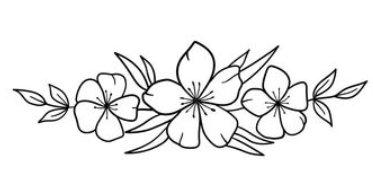
***
# Game Theory Solver 
### Solving Pure and Mixed Strategies 

Pre-requisites

In [1]:
import numpy as np
from tabulate import tabulate

def display_matrix(matrix, title):
    print(f"\n{title}")
    print(tabulate(matrix, tablefmt="fancy_grid"))

Pure Strategy Function
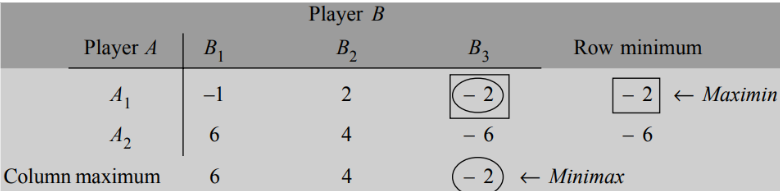

In [2]:
def find_saddle_point(matrix):
    row_min = np.min(matrix, axis=1)
    max_of_row_min = np.max(row_min)
    #maximin
    col_max = np.max(matrix, axis=0)
    min_of_col_max = np.min(col_max)
    #minimax
    if max_of_row_min == min_of_col_max:
        return max_of_row_min
    else:
        return None

Mixed Strategy Functions
<br>
Optimal Strategy formulae:
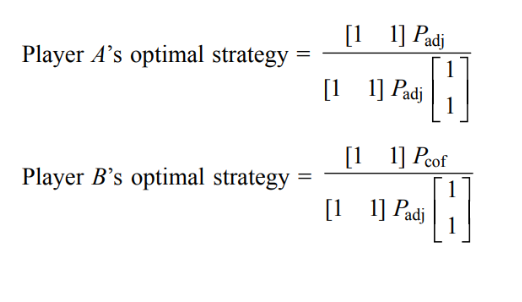
Value of the game = (Player A’s optimal strategies) × (Payoff matrix) × (Player B’s optimal strategies)

In [3]:
def get_determinant(matrix):
    return np.linalg.det(matrix)

def eliminate_dominated_strategies(matrix):
    reduced_matrix = np.array(matrix)
    rows_to_keep = list(range(reduced_matrix.shape[0]))
    #Dominance principle 
    # Eliminate dominated row
    for i in range(reduced_matrix.shape[0]):
        for j in range(reduced_matrix.shape[0]):
            if i != j and i in rows_to_keep and j in rows_to_keep:
                if np.all(reduced_matrix[i] <= reduced_matrix[j]):
                    rows_to_keep.remove(i)
                    print(f"Row {i + 1} is dominated by Row {j + 1} and is removed.")
                    break

    reduced_matrix = reduced_matrix[rows_to_keep, :]

    # Eliminate dominant column
    cols_to_keep = list(range(reduced_matrix.shape[1]))
    for i in range(reduced_matrix.shape[1]):
        for j in range(reduced_matrix.shape[1]):
            if i != j and i in cols_to_keep and j in cols_to_keep:
                if np.all(reduced_matrix[:, i] >= reduced_matrix[:, j]):
                    cols_to_keep.remove(i)
                    print(f"Column {i + 1} dominates Column {j + 1} and is removed.")
                    break

    reduced_matrix = reduced_matrix[:, cols_to_keep]
    display_matrix(reduced_matrix, "Reduced Matrix after Applying Dominance Rule")
    return reduced_matrix

def calculate_optimal_strategy(matrix):
   
        a, b = matrix[0, 0], matrix[0, 1]
        c, d = matrix[1, 0], matrix[1, 1]
        adj_matrix = np.array([[d, -b], [-c, a]])
        display_matrix(adj_matrix, "Adjoint Matrix")
        #using shorcut to find adjoint

        ones_vector = np.ones(matrix.shape[0])
        numerator_a = np.dot(ones_vector, adj_matrix)
        denominator_a = np.dot(numerator_a, ones_vector.T)
        strategy_a = numerator_a / denominator_a
        print("\nOptimal Strategy for Player A:")
        print(f"Numerator: {numerator_a}")
        print(f"Denominator: {denominator_a}")
        print(f"Strategy for row player: {strategy_a}")

        cofactor_matrix = np.array([[d, -c], [-b, a]])
        display_matrix(cofactor_matrix, "Cofactor Matrix")

        numerator_b = np.dot(ones_vector, cofactor_matrix)
        denominator_b = np.dot(numerator_a, ones_vector.T)
        strategy_b = numerator_b / denominator_b
        print("\nOptimal Strategy for Player B:")
        print(f"Numerator: {numerator_b}")
        print(f"Denominator: {denominator_b}")
        print(f"Strategy for column player: {strategy_b}")

        value_of_game = np.dot(np.dot(strategy_a, matrix), strategy_b)
        print(f"\nValue of the Game: {value_of_game}")

Final Function for Solving the Game

In [4]:
def solve_game(matrix):
    display_matrix(matrix, "Initial Matrix")
    saddle_point = find_saddle_point(matrix)
    if saddle_point is not None:
        print(f"\nThe saddle point of the matrix is: {saddle_point}")
    else:
        print("\nThere is no saddle point in the given matrix.")
        choice = input("Would you like to determine an optimal mixture of strategies using the mixed strategy method? (yes/no): ").lower()
        if choice == 'yes':
            reduced_matrix = eliminate_dominated_strategies(matrix)
            if reduced_matrix.shape == (2, 2):
                det = get_determinant(reduced_matrix)
                if np.isclose(det, 0):
                    print("\nThe determinant of the matrix is zero. The matrix is singular, and the optimal mixed strategy cannot be computed using this method.")
                else:
                    calculate_optimal_strategy(reduced_matrix)
            else:
                print("\nThe reduced matrix is not 2x2. Optimal mixed strategy calculation using this method is not possible.")
        else:
            print("\nNo further calculations were performed.")


# Example for Pure Strategy
***

##  Assume that two firms are competing for the market share for a particular product. Each firm is considering what promotional strategy to employ for the coming period. Assume that the following payoff matrix describes the increase in market share of Firm A and the decrease in market share for Firm B. Determine the optimal strategies for each firm.
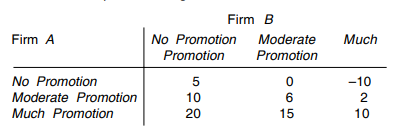

In [5]:
matrix = np.array([[5, 0, -10], [10, 6, 2], [20, 15, 10]], dtype=float)
solve_game(matrix)


Initial Matrix
╒════╤════╤═════╕
│  5 │  0 │ -10 │
├────┼────┼─────┤
│ 10 │  6 │   2 │
├────┼────┼─────┤
│ 20 │ 15 │  10 │
╘════╧════╧═════╛

The saddle point of the matrix is: 10.0


## According to this, the optimal strategy for both the firms is to do Much Promotion.
***
## Example for Mixed Strategy

In an election campaign, the strategies adopted by the ruling and
opposition parties, along with payoffs, (ruling party’s per cent
share in votes polled) are given below:
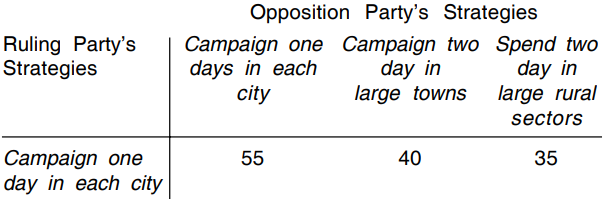 
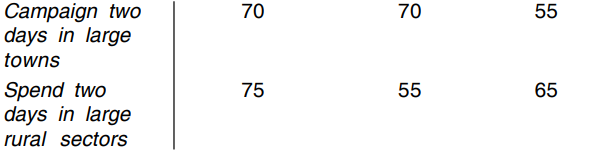

Assume a zero-sum game. Find the optimum strategies for both parties and expected payoff to ruling party.

In [6]:
matrix = np.array([[55, 40, 35], [70, 70, 55], [75, 55, 65]], dtype=float)
solve_game(matrix)


Initial Matrix
╒════╤════╤════╕
│ 55 │ 40 │ 35 │
├────┼────┼────┤
│ 70 │ 70 │ 55 │
├────┼────┼────┤
│ 75 │ 55 │ 65 │
╘════╧════╧════╛

There is no saddle point in the given matrix.
Would you like to determine an optimal mixture of strategies using the mixed strategy method? (yes/no): yes
Row 1 is dominated by Row 2 and is removed.
Column 1 dominates Column 2 and is removed.

Reduced Matrix after Applying Dominance Rule
╒════╤════╕
│ 70 │ 55 │
├────┼────┤
│ 55 │ 65 │
╘════╧════╛

Adjoint Matrix
╒═════╤═════╕
│  65 │ -55 │
├─────┼─────┤
│ -55 │  70 │
╘═════╧═════╛

Optimal Strategy for Player A:
Numerator: [10. 15.]
Denominator: 25.0
Strategy for row player: [0.4 0.6]

Cofactor Matrix
╒═════╤═════╕
│  65 │ -55 │
├─────┼─────┤
│ -55 │  70 │
╘═════╧═════╛

Optimal Strategy for Player B:
Numerator: [10. 15.]
Denominator: 25.0
Strategy for column player: [0.4 0.6]

Value of the Game: 61.0


## Input the matrix for your question below

In [ ]:
print("Enter the elements of the 3x3 matrix row by row:")
matrix = []
for i in range(3):
    row = list(map(float, input(f"Enter the elements of row {i + 1} separated by spaces: ").split()))
    if len(row) != 3:
        print("Please enter exactly 3 numbers in each row.")
        exit()
    matrix.append(row)

matrix = np.array(matrix)
solve_game(matrix)


Enter the elements of the 3x3 matrix row by row:


Thank you :)
***
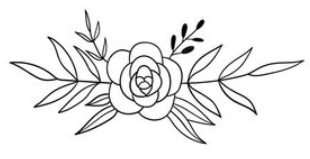